
<h1 align="center"> <strong>DeepSeek OCR</strong> </h1>
<h3 align="center"> From Contexts Optical Compression to A New Paradigm Multi-modality </h3>

----

<div align="center"> Nathmath Huang </div>
<div align="center"> Dec 09, 2025 </div>

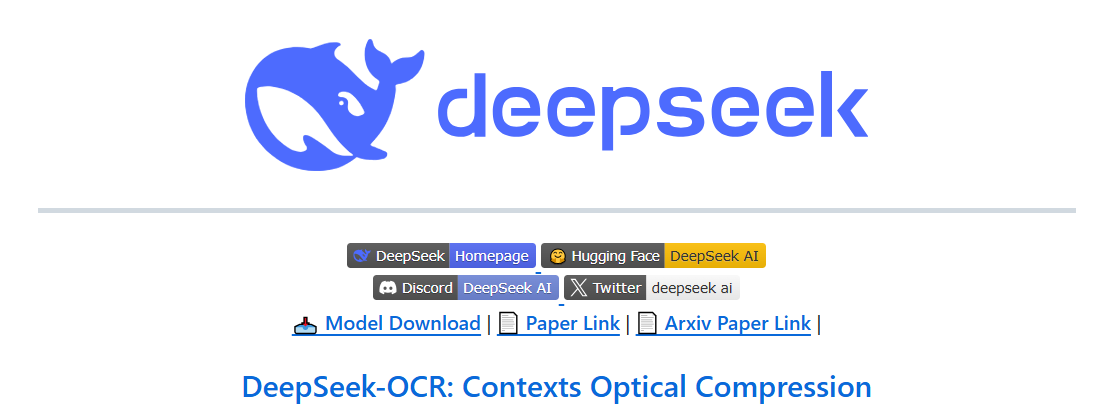

<h2 align="center"> <strong>1. Introduction to DeepSeek-OCR</strong> </h2> 

### What’s DeepSeek-OCR?

- It is an open-weight <span style="color:red;">SOTA End-to-end OCR model</span>.
- Its techniques explore the <span style="color:red;">multimodal representation and storage of long text</span> in LLMs —— **the possibility of visual modality as a compression tool and storage medium** —— breaking away from the text-centric modality.
- It has garnered <span style="color:red;">4 million downloads</span> in just **two months** since its initiaal release this October and has <span style="color:red;">consistently topped the charts</span> on the Hugging Face model website.
- It has only <span style="color:red;">950M</span> activated parameters and works super fast on edge devices, such as my shabby laptop.
- Its <span style="color:red;">ideas are far more meaningful</span> than the experimental models they have released.

### One Paragraph to Conclude The Paper

- The research aims to <span style="color:red;">store long LLM contexts using compressed 2D image representation</span> methods. The research found that <span style="color:red;">text tokens are highly compressible</span> with almost lossless restoration performance - they can be restored by a LLM with 97% accuracy at a token compression ratio of up to 10x, and with a token compression ratio of 20x, text tokens can be restored with 60% accuracy. This <span style="color:red;">lays the foundation for many future studies</span>: for example, compressing context into visual tokens to `achieve longer contexts`, or choosing different compression ratios based on the age of the context to `simulate memory and forgetting mechanisms`. One of the research's achievements is the `DeepSeek-OCR model`, which can complete OCR tasks faster with fewer visual tokens, achieving state-of-the-art status among open-source OCR models with a super small model size.
- Paper url: https://arxiv.org/abs/2510.18234
- Huggingface url: https://huggingface.co/deepseek-ai/DeepSeek-OCR

### How Do We Introduce Today

Their paper is very intensive and comprehensive, so I will discuss it from a perspective of:
- Its marginal contributions
- How to deepen our understanding of LLM/VLM architectures
- Applications that can benefit us

<h2 align="center"> <strong>2. Main Contributions</strong> </h2> 

### First: The possibility of multimodal paradigm shifts

- They studied how to use fewer `vision tokens` to store `complex and lengthy contexts`, extending the meaning of multimodality from <span style="color:red;">visual understanding</span> to <span style="color:red;">optical compression</span>.
- Their experiments have verified that using `visual representations` to `encode text information` can significantly **reduce the consumption of tokens**, thereby providing a <span style="color:red;">possibility to have longer conversations</span> and offering a new theoretical path for the <span style="color:red;">computational efficiency</span> of multimodal systems.
- By selectively `altering the compression ratio`, it may become possible to implement a <span style="color:red;">simulated forgetting mechanism</span> based on changes in the compression ratio, making the AI **more human-like**.

### Second: An Attempt of Measuring the Visual-text Compression Ratio
- The paper is the first to propose using the `ratio of text tokens to visual tokens` to measure <span style="color:red;">optical compression efficiency</span>.
- This metric `measures information density` rather than recognition accuracy, and establishes a compression ratio-fidelity curve, <span style="color:red;">providing a quantifiable indicator</span> for evaluating visual compression in context.
- When text information is compressed `10 times`, the restoration accuracy can be as high as <span style="color:red;">97%</span>.
- When text information is compressed `20 times`, the restoration accuracy is still <span style="color:red;">60%</span>.

We will revisit these two points at the end of this presentation

<h2 align="center"> <strong>3. Architecture Innovations</strong> </h2> 

### Traditional Architectures
![image.png](attachment:40875880-a92e-40b8-954d-5c4be0ee4a45.png)

- **Dual-pipeline structure**: Large images are compressed using SAM, while small images are processed directly through ViT </br>
  Core drawback: <span style="color:red;">Difficult to parallelize the pipelines</span>
- **Global + local structure**: Both local patches and the global image are processed at low resolution through ViT </br>
  Core drawback: <span style="color:red;">Low resolution, excessive segmentation</span>
- **High-resolution dynamic architecture**: Dynamically processes the complete image at high resolution using ViT </br>
  Core drawback: <span style="color:red;">Excessive token waste and inefficiency</span>

### Overall Architecture
![image.png](attachment:fe64bcc5-127c-4577-a668-cbdd7e08b7d6.png)

<h5 align="center">$DeepEncoder$ + $DeepSeek3B$-$MoE$-$A570M$ = $Encoder$-$Decoder$ $Architecture$</h5>

**Encoder-Decoder Architecture**

- It has a large `DeepEncoder` composed of three visual components, followed by a `MoE LLM` as the decoder. The overall structure is very `multi-stage,` with the core objective of **achieving extremely high-quality OCR at high resolution while maintaining controllable speed and token count.**
- `Encoder` responsibilities: Image  <span style="color:red;">feature extraction and tokenization</span>, with  <span style="color:red;">compression</span> along the way.
  Encoder: 380M parameters = 80M SAM + 300M Clip Large
- `Decoder` responsibilities:  <span style="color:red;">Generating results</span> based on the tokens and prompt provided by the Encoder.
  Decoder: 3B MoE LLM, 570M Activated

The actual number of activated parameters is quite small:
$$
80M + 300M + 570M = 950M < 1B
$$

### DeepSeek Encoder

- `Sequential 1` - Slice into pieces - Window-based <span style="color:red;">local attention</span> perception module for feature extraction: `SAM base`
- `Sequential 2` - A 2-layer convolutional module for <span style="color:red;">16x downsampling</span>
- `Sequential 3` - Slices come together - a <span style="color:red;">global attention</span> module for getting a broader understanding: `CLIP large`

### Dataflow Pipeline

```mermaid
flowchart LR
    A[Image Input] --> B[Split into 16×16 patches<br>Each becomes a patch token]
    B --> C[SAM Local Attention]
    C --> D[Convolutional<br> Downsampling ×16]
    D --> E[CLIP Global Attention]
    E --> F[Latent sent to Decoder]
    F --> G[Decoder reconstructs<br> original text tokens]

```

### Still Support Multi-resolution Natively
![image.png](attachment:bf5e7f88-a1e8-443e-beeb-1c402e4b3a36.png)

**Resolutions Supported**

| Mode      | Tiny  |  Small |  Base |  Large |  Gundam     |  Gundam-M     |
|-----------|-------|--------|-------|--------|-------------|---------------|
| Resolution| 512  | 640   | 1024 | 1280  | 640+1024   | 1024+1280    |
| Tokens    | 64   | 100   | 256  | 400   | n×100+256  | n×256+400    |
| Process   | resize | resize | padding | padding | resize + padding | resize + padding |


### Key Takeaways

- It is a large Encoder-Decoder model composed of <span style="color:red;">three cascaded visual components in the encoder</span>, followed by a <span style="color:red;">MoE large language model as the decoder</span>.
- The DeepEncoder is its innovative aspect, particularly the mechanism of using <span style="color:red;">convolutional modules</span> to link local and global attention for compression.

<h2 align="center"> <strong>4. Data and Training</strong> </h2> 


### Data Composition for Training

**Data Overview:**

- **Traditional Data:** <span style="color:red;">30% (Traditional VLM data + plain text)
- **OCR Data:** <span style="color:red;">70%</span>

**Purpose:**
To enable the model to <span style="color:red;">perform OCR tasks</span> while <span style="color:red;">maintaining a foundation of general world knowledge</span>.

**OCR Data = OCR 1.0 + OCR 2.0**

- **OCR 1.0:** `Traditional OCR`, i.e., recognizing text from well-structured documents.
- **OCR 2.0:** Recognition of `more complex systems`, such as charts, formulas, chemical structures, and planar geometry.

### Detailed OCR Data Description

**OCR 1.0: <span style="color:red;">Fundamental OCR with or without layout</span>**

- 30M <span style="color:red;">text based PDFs</span>
- Covers over 100 languages
- English/Chinese accounts for more than $5/6$ of the data; all other languages make up  the remaining $1/6$
- Two versions are prepared: `coarse` version and `delicate` version
- OCR with layout information is extracted using `fitz` and processed via multi-step synthesis
- Enhanced using advanced OCR models, such as GOT-OCR 2.0
- Used some open-source datasets such as https://arxiv.org/abs/2502.18443v3

**OCR 2.0: <span style="color:red;">Complex parsing problems beyond simple text extraction</span>**

- 10M <span style="color:red;">charts and graphs</span> generated using `pyecharts` and `matplotlib`
- 5M <span style="color:red;">chemical diagrams</span> rendered with RDKit from PubChem data
- 1M planar <span style="color:red;">geometry examples</span>
- Small amounts of other specialized data


### Supported OCR Tasks

**OCR 1.0**
- <span style="color:red;">Free-form document OCR</span> (simple OCR)
- <span style="color:red;">Formatted document OCR</span> (with layout)
- Specialized format OCR (e.g. HTML)

**OCR 2.0**
- Natural scene OCR (e.g. recognizing objects like dogs)
- Chart interpretation
- Formula recognition
- Chemical diagram recognition
- Geometric structure recognition

### Regarding Training

Three steps: 
- First, train the <span style="color:red;">DeepEncoder</span>
- Then, further train the <span style="color:red;">whole DeepSeek-OCR</span> based on a pretrained DeepEncoder
- Last, an extra step is training with <span style="color:red;">ultra-high-resolution samples</span> to enable Gundam-master mode

<h2 align="center"> <strong>5. Key Performance Metrics</strong> </h2> 

### Visual-text Compression Ratio and Precision

Evaluated the relationship between compression ratio and restoration quality
| Text Tokens | Precision (VT=64) | Compression (VT=64) | Precision (VT=100) | Compression (VT=100) | Pages |
|-------------|-------------------|----------------------|---------------------|------------------------|-------|
| 600–700     | 96.5%             | 10.5×               | 98.5%               | 6.7×                  | 7     |
| 700–800     | 93.8%             | 11.8×               | 97.3%               | 7.5×                  | 28    |
| 800–900     | 83.8%             | 13.2×               | 96.8%               | 8.5×                  | 28    |
| 900–1000    | 85.9%             | 15.1×               | 96.8%               | 9.7×                  | 14    |
| 1000–1100   | 79.3%             | 16.5×               | 91.5%               | 10.6×                 | 11    |
| 1100–1200   | 76.4%             | 17.7×               | 89.8%               | 11.3×                 | 8     |
| 1200–1300   | 59.1%             | 19.7×               | 87.1%               | 12.6×                 | 4     |


### OmniDocBench Performance with Different Modes

Evaluated performance under different modes (different compression ratios)
| Mode       | Book Slides | Financial Report | Textbook | Exam Paper | Magazine | Academic Papers | Notes | Newspaper | Overall |
|------------|-------------|------------------|----------|------------|----------|------------------|-------|-----------|---------|
| Tiny       | 0.147       | 0.116            | 0.207    | 0.173      | 0.294    | 0.201            | 0.395 | 0.297     | 0.94    | 0.32  |
| Small      | 0.085       | 0.111            | 0.079    | 0.147      | 0.171    | 0.107            | 0.131 | 0.187     | 0.744   | 0.205 |
| Base       | 0.037       | 0.080            | 0.027    | 0.100      | 0.130    | 0.073            | 0.052 | 0.176     | 0.645   | 0.156 |
| Large      | 0.038       | 0.108            | 0.022    | 0.084      | 0.109    | 0.060            | 0.053 | 0.155     | 0.353   | 0.117 |
| Gundam     | 0.035       | 0.085            | 0.289    | 0.095      | 0.094    | 0.059            | 0.039 | 0.153     | 0.122   | 0.083 |
| Gundam-M   | 0.052       | 0.090            | 0.034    | 0.091      | 0.079    | 0.079            | 0.048 | 0.100     | 0.099   | 0.077 |

- Note that it measures editing error, so the lower the better.


### OmniDocBench Cross-model Performance

Compare Editing Error and Token Consumptions
| Model | Tokens | English Overall | English Text | English Formula | English Table | English Order | Chinese Overall | Chinese Text | Chinese Formula | Chinese Table | Chinese Order |
|-------|--------|-----------------|--------------|------------------|----------------|----------------|------------------|---------------|------------------|----------------|----------------|
| **Pipeline Models** |
| Dolphin [11] | - | 0.356 | 0.352 | 0.465 | 0.258 | 0.35 | 0.44 | 0.44 | 0.604 | 0.367 | 0.351 |
| Marker [1] | - | 0.296 | 0.085 | 0.374 | 0.609 | 0.116 | 0.497 | 0.293 | 0.688 | 0.678 | 0.329 |
| Mathpix [2] | - | 0.191 | 0.105 | 0.305 | 0.243 | 0.108 | 0.364 | 0.381 | 0.454 | 0.32 | 0.3 |
| MinerU-2.1.1 [34] | - | 0.162 | 0.072 | 0.314 | 0.067 | 0.094 | 0.191 | 0.051 | 0.381 | 0.188 | 0.136 |
| MonkeyOCR-1.2B [18] | - | 0.154 | 0.062 | 0.295 | 0.164 | 0.094 | 0.263 | 0.179 | 0.464 | 0.168 | 0.243 |
| PPstructure-v3 [9] | - | 0.152 | 0.073 | 0.295 | 0.162 | 0.077 | 0.223 | 0.136 | 0.535 | 0.111 | 0.11 |
| **End-to-end Models** |
| Nougat [6] | 2352 | 0.452 | 0.365 | 0.488 | 0.572 | 0.382 | 0.973 | 0.998 | 0.941 | 1.00 | 0.954 |
| SmolDocling [25] | 392 | 0.493 | 0.262 | 0.753 | 0.729 | 0.227 | 0.816 | 0.389 | 0.997 | 0.502 | 0.888 |
| InternVL2-76B [8] | 6790 | 0.44 | 0.353 | 0.543 | 0.547 | 0.317 | 0.493 | 0.29 | 0.701 | 0.555 | 0.228 |
| Qwen2.5-VL-7B [5] | 3949 | 0.414 | 0.342 | 0.502 | 0.509 | 0.349 | 0.478 | 0.326 | 0.656 | 0.377 | 0.252 |
| OLMOCR [28] | 3949 | 0.367 | 0.199 | 0.459 | 0.411 | 0.349 | 0.461 | 0.29 | 0.555 | 0.627 | 0.227 |
| GOT-OCR2.0 [38] | 256 | 0.298 | 0.087 | 0.306 | 0.523 | 0.289 | 0.481 | 0.305 | 0.655 | 0.572 | 0.276 |
| OCRFlux-3B [3] | 3949 | 0.238 | 0.112 | 0.447 | 0.269 | 0.126 | 0.349 | 0.256 | 0.716 | 0.26 | 0.263 |
| GPT4o [26] | 3920 | 0.33 | 0.144 | 0.425 | 0.234 | 0.126 | 0.399 | 0.136 | 0.632 | 0.28 | 0.276 |
| InternVL3-78B [42] | 6790 | 0.218 | 0.191 | 0.208 | 0.279 | 0.05 | 0.211 | 0.53 | 0.224 | 0.382 | 0.121 |
| Qwen2.5-VL-72B [5] | 3949 | 0.221 | 0.149 | 0.318 | 0.239 | 0.12 | 0.322 | 0.084 | 0.281 | 0.425 | 0.168 |
| dots.ocr [30] | 392 | 0.182 | 0.075 | 0.309 | 0.169 | 0.067 | 0.238 | 0.105 | 0.252 | 0.219 | 0.212 |
| Gemini2.5-Pro [4] | - | 0.148 | 0.034 | 0.245 | 0.111 | 0.074 | 0.243 | 0.053 | 0.209 | 0.196 | 0.121 |
| MinerU2.0 [34] | 6790 | 0.135 | 0.065 | 0.142 | 0.086 | 0.062 | 0.118 | 0.115 | 0.209 | 0.09 | 0.122 |
| dots.ocr†200dpi [30] | 5545 | 0.125 | 0.032 | 0.329 | 0.099 | 0.04 | 0.16 | 0.066 | 0.416 | 0.092 | 0.067 |
| **DeepSeek-OCR (end2end)** |
| <span style="color:red">Tiny</span> | <span style="color:red">64</span> | <span style="color:red">0.386</span> | <span style="color:red">0.373</span> | <span style="color:red">0.469</span> | <span style="color:red">0.422</span> | <span style="color:red">0.283</span> | <span style="color:red">0.361</span> | <span style="color:red">0.307</span> | <span style="color:red">0.635</span> | <span style="color:red">0.266</span> | <span style="color:red">0.236</span> |
| <span style="color:red">Small</span> | <span style="color:red">100</span> | <span style="color:red">0.211</span> | <span style="color:red">0.142</span> | <span style="color:red">0.209</span> | <span style="color:red">0.242</span> | <span style="color:red">0.134</span> | <span style="color:red">0.241</span> | <span style="color:red">0.124</span> | <span style="color:red">0.25</span> | <span style="color:red">0.159</span> | <span style="color:red">0.209</span> |
| <span style="color:red">Base</span> | <span style="color:red">256</span> | <span style="color:red">0.137</span> | <span style="color:red">0.054</span> | <span style="color:red">0.247</span> | <span style="color:red">0.16</span> | <span style="color:red">0.034</span> | <span style="color:red">0.24</span> | <span style="color:red">0.054</span> | <span style="color:red">0.474</span> | <span style="color:red">0.081</span> | <span style="color:red">0.184</span> |
| <span style="color:red">Large</span> | <span style="color:red">400</span> | <span style="color:red">0.127</span> | <span style="color:red">0.043</span> | <span style="color:red">0.299</span> | <span style="color:red">0.162</span> | <span style="color:red">0.061</span> | <span style="color:red">0.271</span> | <span style="color:red">0.065</span> | <span style="color:red">0.409</span> | <span style="color:red">0.075</span> | <span style="color:red">0.211</span> |
| <span style="color:red">Gundam</span> | <span style="color:red">795</span> | <span style="color:red">0.243</span> | <span style="color:red">0.059</span> | <span style="color:red">0.247</span> | <span style="color:red">0.446</span> | <span style="color:red">0.017</span> | <span style="color:red">0.164</span> | <span style="color:red">0.047</span> | <span style="color:red">0.432</span> | <span style="color:red">0.089</span> | <span style="color:red">0.103</span> |
| <span style="color:red">Gundam-M†200dpi</span> | <span style="color:red">1853</span> | <span style="color:red">**0.123**</span> | <span style="color:red">0.049</span> | <span style="color:red">**0.242**</span> | <span style="color:red">0.147</span> | <span style="color:red">0.056</span> | <span style="color:red">**0.157**</span> | <span style="color:red">0.087</span> | <span style="color:red">**0.377**</span> | <span style="color:red">0.08</span> | <span style="color:red">0.085</span> |

- Note that it measures editing error, so the lower the better.

### A Custom Challenging Benchmark

A Multilingual Dataset Having Handwritting and Challenging Tasks
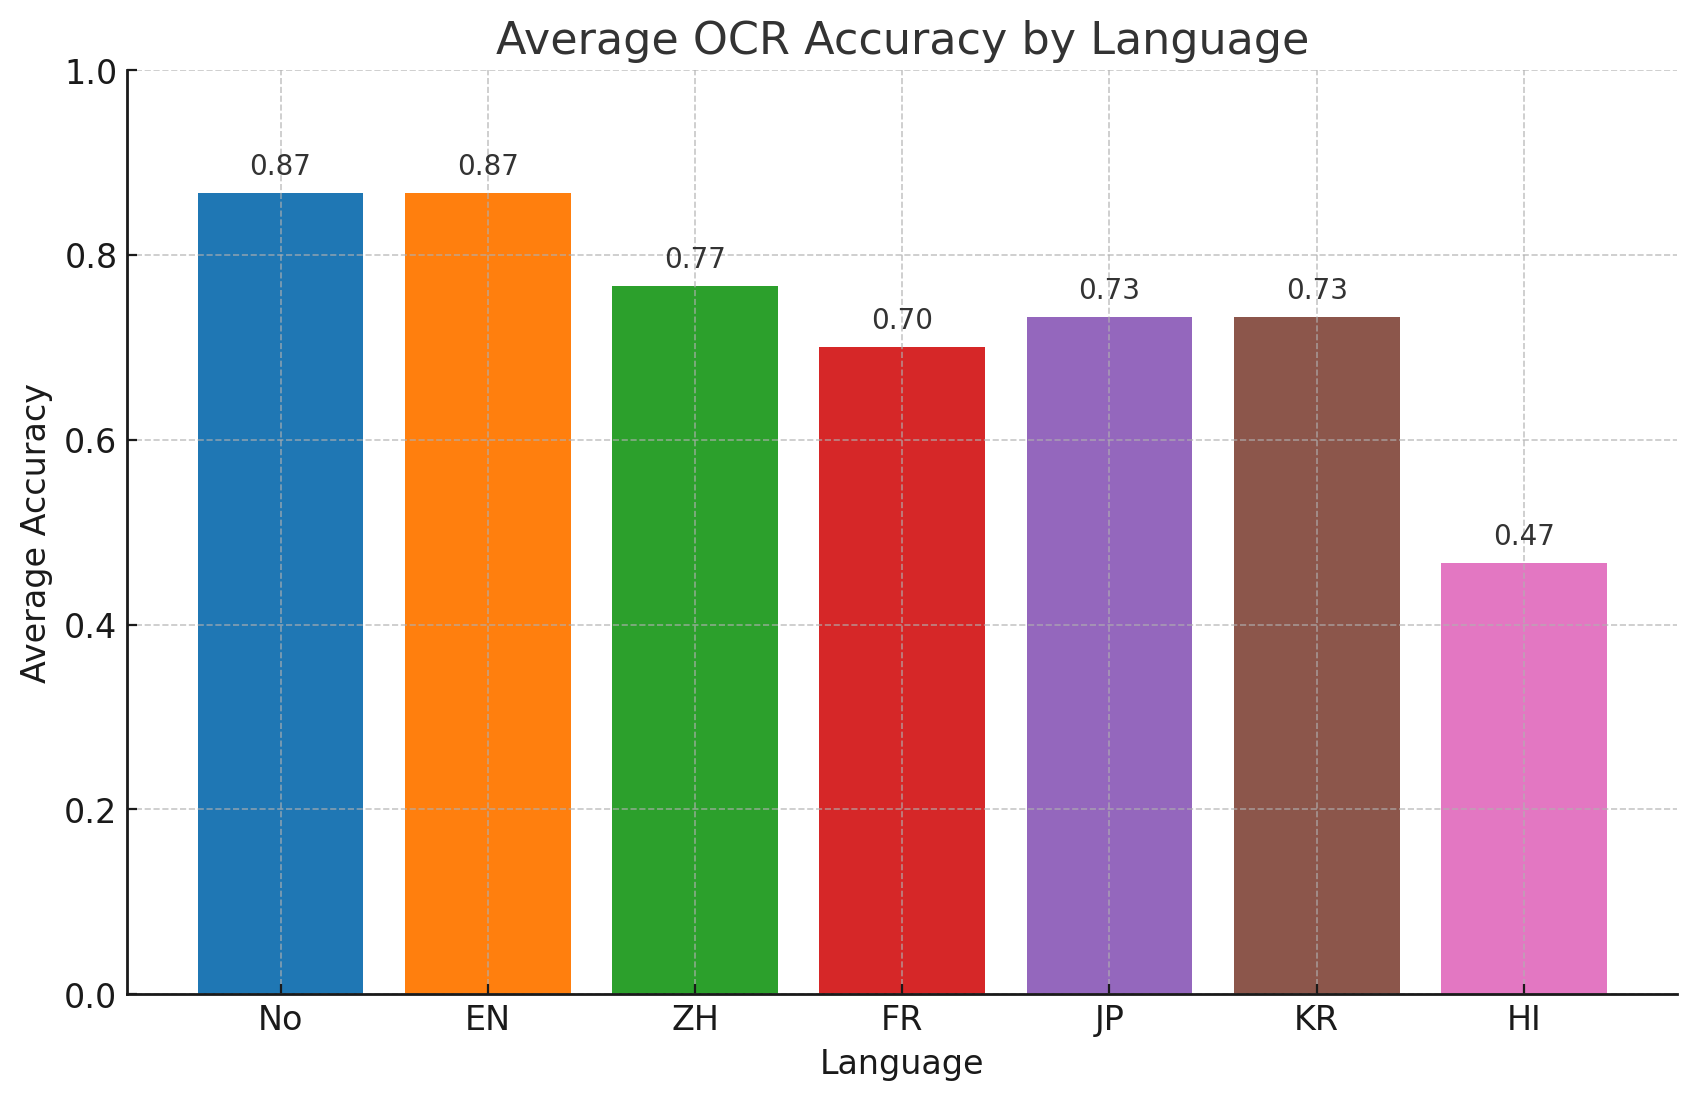

- Note that this is created and operated by myself.
- Each language has 45 deliberately chosen samples and they are challenging.
- I give `1` for exactly no error, `0.5` for a few errors, `0` for a lot of errors.

### Additional Information 

Pros:
- **<span style="color:red;">Good</span> at printed documents**
- **<span style="color:red;">Good</span> at printed formulas**
- **<span style="color:red;">Good</span> at EN/ZH handwriting documents**
- **<span style="color:red;">Good</span> at numbers**

Cons:
- **<span style="color:red;">Bad</span> at handwriting formulas**
- **<span style="color:red;">Bad</span> at handwriting in rare languages**
- **Sometimes misdetect languages when mixed**

### Application Possibilities

1. Traditional OCR/ Handwritten OCR
2. Deep Parsing
3. General Vision Understanding
4. Object Locating

You can try `DeepSeek-OCR` <span style="color:red;">online</span> using a thridparty hugging face space: https://huggingface.co/spaces/merterbak/DeepSeek-OCR-Demo

Or <span style="color:red;">deploy it locally</span> to preserve privacy either by using `code` or `dof-studio/DSOCR` integrated environment developed by myself: https://github.com/dof-studio/DSOCR

<h2 align="center"> <strong>6. Future Prospects</strong> </h2> 

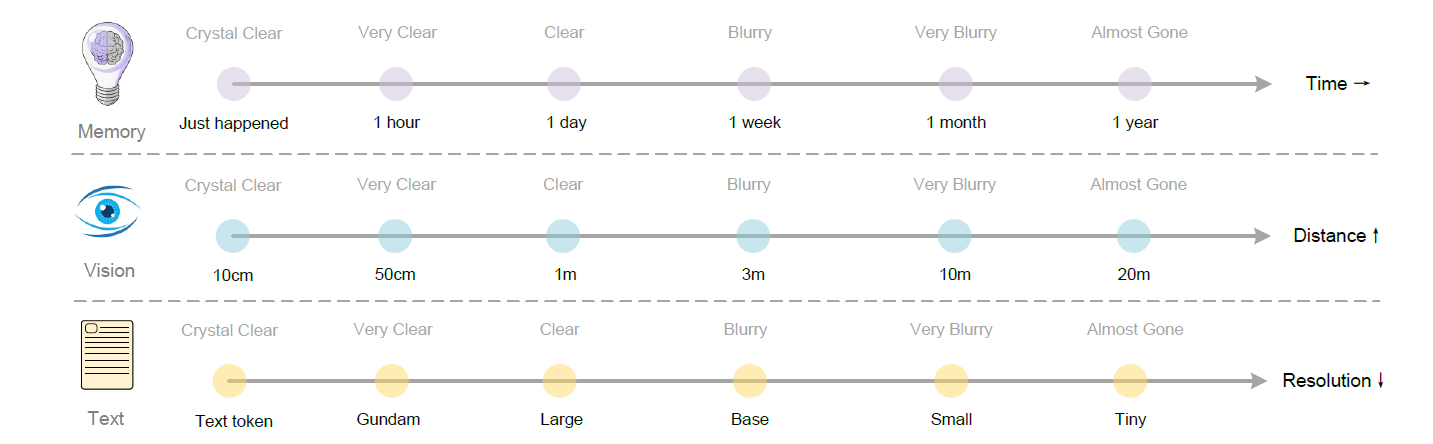

### Prospects

1. **Dialog Conversation Compression** - By compressing the historical context into visual tokens, it can achieve at least a <span style="color:red;">10x reduction in total token usage</span>, thus supporting more effective context and ·longer multi-turn conversations· without changing the Decoder architecture.
3. **Simulate Forgetting Mechanism** - By using different compression ratios for different stages of context, either <span style="color:red;">precise or fuzzy</span> compression can be naturally generated, which simulates the human memory system.
4. **LLM + Forgetting Mechanism = More feeling like a human** - Forgetting is a merit of moving forward. Teaching large language models (LLMs) to forget is a very promising and futuristic field that still requires further research.

### Intutions of Why Optical Compression Makes Sense

- Images can naturally present much more <span style="color:red;">complex contextual relationships</span> from a two-dimensional perspective than texts.
- Natural language is very <span style="color:red;">sparse</span>; often, just abbreviations or keywords can convey rich meanings.
- Models have already <span style="color:red;">acquired extensive world knowledge</span> during pretraining, so many times, only **a small hint** is needed for them to infer/recall the full context.
- Humans have very mature frameworks for AI to <span style="color:red;">process and compress images</span>, such as CNNs.

A not-so-appropriate example：

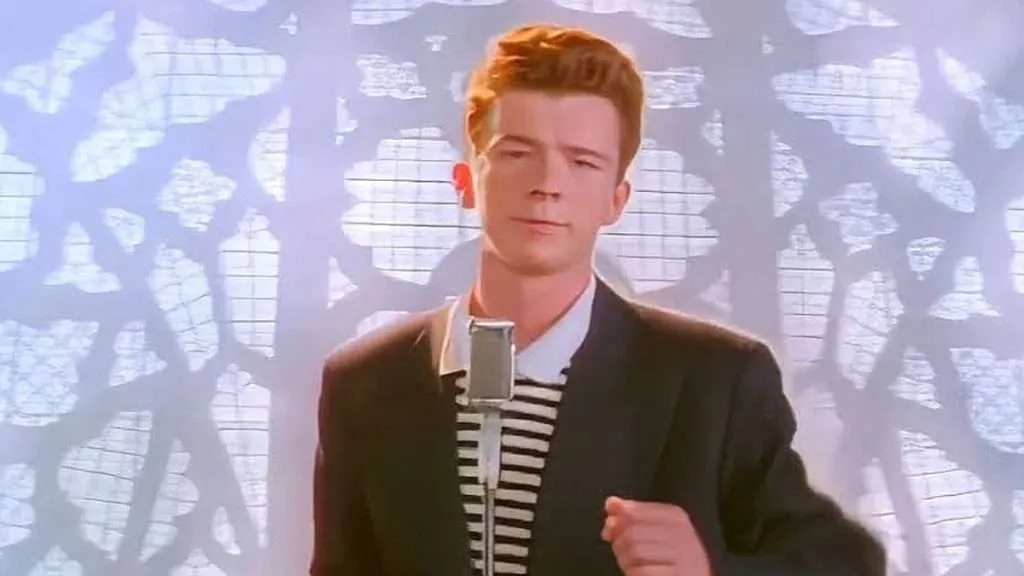


----

Thank you for reading this and listening to my presentation.